# Laboratorio Razonamiento - Diplomado IA Educacion Continua UC

In [ ]:
!pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu128

!pip install "absl-py"==1.4.0 \
    accelerate==1.13.0 \
    einops==0.8.2 \
    evaluate==0.4.6 \
    gdown==5.2.1 \
    liger-kernel==0.7.0 \
    ml_dtypes==0.5.4 \
    nltk==3.9.1 \
    numpy==2.0.2 \
    packaging==26.0 \
    pandas==2.2.2 \
    peft==0.18.1 \
    torchao==0.10.0 \
    torchdata==0.11.0 \
    torchsummary==1.5.1 \
    torchtune==0.6.1 \
    tqdm==4.67.3 \
    transformers==5.5.0 \
    trl==1.0.0 \
    rapidfuzz==3.14.3 \
    dspy==3.1.3 \
    bitsandbytes==0.49.2

Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.5/276.5 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.4/312.4 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 50.0 MB/s eta 0:00:00

In [ ]:
!gdown 1wGcNYF4tqXb7j20IWJibzdTO0dyfeUyj
!gdown 1YlHIj-8eVCdDglIrPju4uw1OGwBwacNq

Downloading...
From: https://drive.google.com/uc?id=1wGcNYF4tqXb7j20IWJibzdTO0dyfeUyj
To: /content/conversations_qw_3_6p_2.zip
100% 5.04M/5.04M [00:00<00:00, 186MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YlHIj-8eVCdDglIrPju4uw1OGwBwacNq
To: /content/dict_A_to_I.txt
100% 8.98M/8.98M [00:00<00:00, 59.5MB/s]


In [ ]:
!unzip conversations_qw_3_6p_2.zip

Archive:  conversations_qw_3_6p_2.zip
   creating: conversations_qw_3_6p_2/
  inflating: __MACOSX/._conversations_qw_3_6p_2  
  inflating: conversations_qw_3_6p_2/conversation_416_The_girl_looked_for.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_416_The_girl_looked_for.jsonl  
  inflating: conversations_qw_3_6p_2/conversation_117_Yes__I_eat_chili.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_117_Yes__I_eat_chili.jsonl  
  inflating: conversations_qw_3_6p_2/conversation_309_She_hugged_me.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_309_She_hugged_me.jsonl  
  inflating: conversations_qw_3_6p_2/conversation_514_Do_you_like_Japanese.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_514_Do_you_like_Japanese.jsonl  
  inflating: conversations_qw_3_6p_2/conversation_551_I_am_a_cat.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_551_I_am_a_cat.jsonl  
  inflating: conversations_qw_3_6

# Uso de herramientas

Vamos a darle a un modelo la capacidad de usar un diccionario del idioma Lakota, y vamos a pedirle que lo utilice para realizar traducciones desde el ingles.

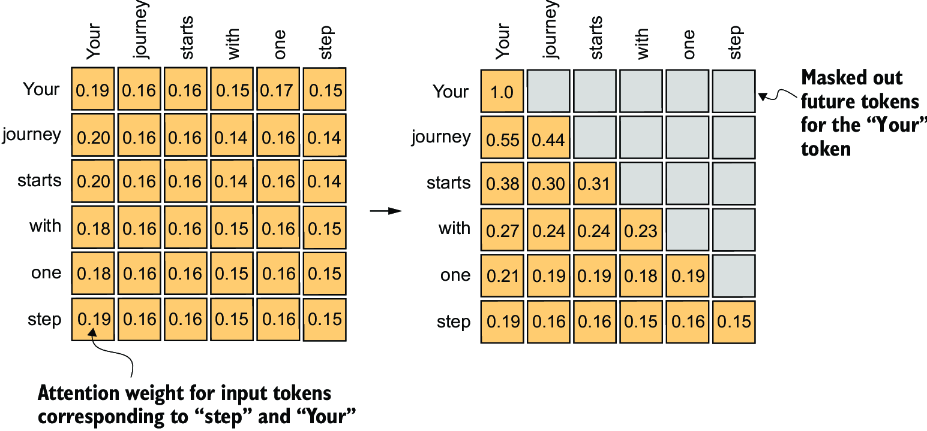

In [ ]:
import json
import re
import threading
import unicodedata

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TextIteratorStreamer
from rapidfuzz import fuzz


# A continuación se encuentra nuestro diccionaro, esta es una clase que recibe
# texto y retorna las entradas del diccionario con mayor correspondencia
# con el input de la busqueda

class LakotaDictionaryTool:
    def __init__(self, raw_data):
        self.entries = self._parse_data(raw_data)

    def _parse_data(self, data):
        entries = []
        for raw_entry in re.split(r"(?=\\lx )", data):
            if not raw_entry.strip():
                continue
            entry_obj = {"lexeme": "", "senses": []}
            current_sense = {"definition": "", "examples": []}
            for line in raw_entry.strip().split("\n"):
                m = re.match(r"^\\(\w+)\s+(.*)", line.strip())
                if not m:
                    continue
                marker, content = m.groups()
                if marker == "lx":
                    entry_obj["lexeme"] = content
                elif marker == "ps":
                    entry_obj["part_of_speech"] = content
                elif marker == "sn":
                    if current_sense["definition"] or current_sense["examples"]:
                        entry_obj["senses"].append(current_sense)
                    current_sense = {"definition": "", "examples": [], "usage": "", "sense_number": content}
                elif marker == "de":
                    current_sense["definition"] = content
                elif marker == "ue":
                    current_sense["usage"] = content
                elif marker == "xv":
                    current_sense["examples"].append({"lakota": content, "english": ""})
                elif marker == "xe" and current_sense["examples"]:
                    current_sense["examples"][-1]["english"] = content
            if current_sense["definition"] or current_sense["examples"]:
                entry_obj["senses"].append(current_sense)
            if entry_obj["lexeme"]:
                entries.append(entry_obj)
        return entries

    def _norm(self, text):
        if not text:
            return ""
        text = text.replace("ŋ", "n").replace("Ŋ", "N")
        text = unicodedata.normalize("NFD", text)
        return "".join(c for c in text if unicodedata.category(c) != "Mn").lower().strip()

    def _fuzzy(self, query, text, nq=None, nt=None):
        if not text:
            return 0.0
        nq = nq or self._norm(query)
        nt = nt or self._norm(text)
        if nq == nt:
            return 1.0
        return max((fuzz.ratio(nq, w) / 100.0 for w in re.findall(r"\w+", nt)), default=0.0)

    def _exact_word(self, q, t):
        return bool(t and q and re.search(r"\b" + re.escape(q) + r"\b", t))

    def search(self, query, limit=5, threshold=0.65):
        results = []
        nq = self._norm(query)
        for entry in self.entries:
            best = 0.0
            lx = entry.get("lexeme", "")
            nlx = self._norm(lx)
            best = max(best, 3.0 if nlx == nq else self._fuzzy(query, lx, nq, nlx) * 1.5)
            for sense in entry["senses"]:
                d = sense.get("definition", "")
                nd = self._norm(d)
                if nd == nq:
                    best = max(best, 2.5)
                elif self._exact_word(nq, nd):
                    best = max(best, 2.1)
                else:
                    penalty = 0.9 if len(nd) > len(nq) * 3 else 1.0
                    best = max(best, self._fuzzy(query, d, nq, nd) * penalty)
                for ex in sense.get("examples", []):
                    for field, exact_s, mult in [("lakota", 2.8, 0.8), ("english", 2.3, 0.8)]:
                        raw = ex.get(field, "")
                        nr = self._norm(raw)
                        if nr == nq:
                            best = max(best, exact_s)
                        elif self._exact_word(nq, nr):
                            best = max(best, exact_s - 0.6)
                        else:
                            best = max(best, self._fuzzy(query, raw, nq, nr) * mult)
            if best >= threshold:
                results.append((best, entry))
        results.sort(key=lambda x: -x[0])
        return [r[1] for r in results[:limit]]

    def format_results(self, results):
        if not results:
            return "No results found."
        lines = []
        for entry in results:
            line = f"**{entry.get('lexeme', '?')}** ({entry.get('part_of_speech', 'pk')})"
            senses = entry.get("senses", [])
            for i, s in enumerate(senses, 1):
                prefix = f" {i}. " if len(senses) > 1 else " "
                line += f"{prefix}{s.get('definition', '').strip()}"
                if s.get("usage", "").strip():
                    line += f" [Note: {s['usage'].strip()}]"
                if s.get("examples"):
                    exs = "; ".join(f"{e['lakota']} -> {e['english']}" for e in s["examples"])
                    line += f" | Example: {exs}"
            lines.append(line)
        return "\n".join(lines)


# Definimos las herramientas existentes,
# el formato a utilizar depende del modelo a usar
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "search_dictionary",
            "description": "Performs a fuzzy text search on the Lakota dictionary.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "The word or definition to search for."},
                    "limit": {"type": "integer", "description": "Max results (default 4).", "default": 4},
                },
                "required": ["query"],
            },
        },
    }
]

# Esta es la instruccion que le entregaremos al modelo,
# es utilizada para variar su comportamiento

SYSTEM_PROMPT_TEMPLATE = """# Tools

You have access to the following functions:

<tools>
{tools_block}
</tools>

<tool_call>
<function=example_function_name>
<parameter=example_parameter_1>
value_1
</parameter>
</function>
</tool_call>

Reminder:
- Function calls MUST follow the specified format: an inner <function=...></function> block must be nested within <tool_call></tool_call> XML tags.
- Required parameters MUST be specified.

You are a careful English-to-Lakota translator.

Rules:
1. For every translation request, use the search_dictionary function at least once before giving the final translation.
2. You may call the dictionary multiple times to verify roots, alternate spellings, affixes, or meanings.
3. Prefer conservative translations grounded in the dictionary results.
4. You have a maximum of {max_turns} turns available, there is no limit to the number of tool calls in total or per turn, but find the necessary words efficiently and provide the final answer before exceeding this limit.
5. In the final answer, output:
   - Lakota: <final translation>
   - Notes: <brief explanation of word choices and uncertainty if any>
6. Do not invent dictionary evidence that was not returned by the tool.
7. You do not have to rely entirely on exact definitions, the tool results can include examples of translations from which you can infer the meaning of the word in the context of the sentence.
8. It is recommended to perform multiple tool calls in parallel.
"""

TOOL_CALL_RE = re.compile(r"<tool_call>\s*<function=([^\n>]+)>\s*(.*?)</function>\s*</tool_call>", re.DOTALL)
PARAM_RE = re.compile(r"<parameter=([^>\n]+)>\s*(.*?)\s*</parameter>", re.DOTALL)


def parse_tool_calls(text):
    calls = []
    for fn_name, fn_body in TOOL_CALL_RE.findall(text or ""):
        args = {}
        for pname, pval in PARAM_RE.findall(fn_body):
            try:
                args[pname.strip()] = json.loads(pval.strip())
            except Exception:
                args[pname.strip()] = pval.strip()
        calls.append({"name": fn_name.strip(), "arguments": args})
    return calls


def execute_tool_call(name, args, dictionary_tool):
    if name != "search_dictionary":
        return f"ERROR: Unknown tool '{name}'."
    query = args.get("query")
    if not isinstance(query, str) or not query.strip():
        return "ERROR: search_dictionary requires a non-empty string 'query'."
    limit = int(args.get("limit", 4))
    return dictionary_tool.format_results(dictionary_tool.search(query=query, limit=limit))


def load_model(model_name="Qwen/Qwen3-4B", lora_path=None, load_in_4bit=False, flash_attn=False):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, padding_side="left")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    bnb_config = None
    if load_in_4bit:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
        )

    model = AutoModelForCausalLM.from_pretrained(
        model_name, trust_remote_code=True, quantization_config=bnb_config,
        torch_dtype=torch.bfloat16 if not load_in_4bit else None,
        device_map="auto",
        attn_implementation="flash_attention_2" if flash_attn else None,
    )

    if lora_path:
        from peft import PeftModel
        model = PeftModel.from_pretrained(model, lora_path).merge_and_unload()

    model.eval()
    return model, tokenizer

def _build_eos_token_ids(tokenizer):
    eos_token_ids = []
    if tokenizer.eos_token_id is not None:
        eos_token_ids.append(tokenizer.eos_token_id)

    vocab = tokenizer.get_vocab()
    for token in ["<|im_end|>", "<|endoftext|>"]:
        token_id = vocab.get(token)
        if token_id is not None and token_id not in eos_token_ids:
            eos_token_ids.append(token_id)

    return eos_token_ids


def _clean_generated_text(text: str) -> str:
    cutoff_markers = [
        "<tool_response>",
        "user\n<tool_response>",
        "user\n",
    ]
    for marker in cutoff_markers:
        if marker in text:
            text = text.split(marker)[0]
    return text.strip()


def _render_chat(tokenizer, messages, add_generation_prompt: bool) -> str:
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=add_generation_prompt,
        enable_thinking=True,
    )


def _build_incremental_input_ids(tokenizer, cached_messages, current_messages, device):
    full_text = _render_chat(tokenizer, current_messages, add_generation_prompt=True)

    if not cached_messages:
        input_ids = tokenizer(
            full_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(device)
        return input_ids, False

    cached_text = _render_chat(tokenizer, cached_messages, add_generation_prompt=False)

    if full_text.startswith(cached_text):
        delta_text = full_text[len(cached_text):]
        input_ids = tokenizer(
            delta_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(device)
        return input_ids, False

    input_ids = tokenizer(
        full_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).input_ids.to(device)
    return input_ids, True


def generate(
    model,
    tokenizer,
    input_ids,
    past_key_values=None, # Parametro importante, cache
    max_new_tokens=2048,
    temperature=0.6,
    stream=False,
):
    eos_token_id = _build_eos_token_ids(tokenizer)

    gen_kwargs = dict(
        input_ids=input_ids,
        past_key_values=past_key_values,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=eos_token_id,
        # En general los modelos tienen parametros de muestreo recomendados
        # con los que generan mejores respuestas (mayor puntaje en algun benchmark)
        # https://huggingface.co/Qwen/Qwen3.5-2B#best-practices
        temperature=1.0,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
        repetition_penalty=1.0,
        return_dict_in_generate=True,
        use_cache=True,
        stop_strings=["<tool_response>", "<|im_start|>", "user\n<tool_response>"],
        tokenizer=tokenizer,
    )

    if stream:
        streamer = TextIteratorStreamer(
            tokenizer,
            skip_prompt=True,
            skip_special_tokens=False,
        )
        gen_kwargs["streamer"] = streamer

        output_container = {}

        def target():
            with torch.no_grad():
                output_container["result"] = model.generate(**gen_kwargs)

        thread = threading.Thread(target=target)
        thread.start()

        for chunk in streamer:
            print(chunk, end="", flush=True)
        print()

        thread.join()
        outputs = output_container["result"]
    else:
        with torch.no_grad():
            outputs = model.generate(**gen_kwargs)

    # Decode only newly generated tokens relative to THIS call's input_ids
    gen_tokens = outputs.sequences[0, input_ids.shape[1]:]
    generated_text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
    generated_text = _clean_generated_text(generated_text)

    new_past_key_values = getattr(outputs, "past_key_values", None)
    return generated_text, new_past_key_values


def translate(
    english_text,
    dictionary_tool,
    model,
    tokenizer,
    max_turns=5,
    max_new_tokens=2048,
    temperature=0.6,
    stream=False,
    output_file=None,
):
    tools_block = "\n".join(json.dumps(t, ensure_ascii=False) for t in TOOLS)
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        tools_block=tools_block,
        max_turns=max_turns,
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": f"Translate the following English text into Lakota.\n\nEnglish: {english_text}",
        },
    ]

    # Messages already represented by the current KV cache.
    cached_messages = []
    past_key_values = None
    assistant_text = ""

    for step in range(max_turns + 1):
        print(f"\n--- Turn {step + 1} ---")

        current_input_ids, reset_cache = _build_incremental_input_ids(
            tokenizer=tokenizer,
            cached_messages=cached_messages,
            current_messages=messages,
            device=model.device,
        )

        if reset_cache:
            past_key_values = None

        assistant_text, past_key_values = generate(
            model=model,
            tokenizer=tokenizer,
            input_ids=current_input_ids,
            past_key_values=past_key_values,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            stream=stream,
        )

        if not stream:
            print(f"Assistant:\n{assistant_text}")

        messages.append({"role": "assistant", "content": assistant_text})

        # Cache now represents everything up through this assistant turn.
        cached_messages = list(messages)

        tool_calls = parse_tool_calls(assistant_text)

        if not tool_calls:
            print("\nDone (no tool calls).")
            break

        if step == max_turns:
            raise RuntimeError("Model attempted tool call after max turns exhausted.")

        tool_response_blocks = []
        for tc in tool_calls:
            print(f"  Tool: {tc['name']}({tc['arguments']})")
            output = execute_tool_call(tc["name"], tc["arguments"], dictionary_tool)
            print(f"  Result: {output}")
            tool_response_blocks.append(f"<tool_response>\n{output}\n</tool_response>")

        steps_left = max_turns - step - 1
        if steps_left > 0:
            reminder = (
                f"\n\n<system_reminder>You have {steps_left} turn(s) left. "
                "Please provide the final translation if you have enough information."
                "</system_reminder>"
            )
        else:
            reminder = (
                "\n\n<system_reminder>You have 0 turns left for dictionary searches. "
                "You MUST provide the final Lakota translation now in your next response "
                "without using any more tools.</system_reminder>"
            )

        tool_content = "\n".join(tool_response_blocks) + reminder
        messages.append({"role": "user", "content": tool_content})

    if output_file:
        with open(output_file, "w", encoding="utf-8") as f:
            for msg in messages:
                f.write(json.dumps(msg, ensure_ascii=False) + "\n")
        print(f"Saved to {output_file}")

    return assistant_text.strip(), messages

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

# La architectura de modelos Qwen de Alibaba es muy utilizada,
# tiene uno de los mejores desempenos en relacion a su tamano
# y tiene gran variedad en tamanos de modelos, utiles en distintas
# capacidades de hardware, los mas pequenos son de 0.8, 2 y 4 billones de
# parametros
base_model_id = "Qwen/Qwen3.5-2B"

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    device_map="cuda"
)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [ ]:
raw_data = open("dict_A_to_I.txt", "r", encoding="utf-8").read()
dictionary_tool = LakotaDictionaryTool(raw_data)

In [ ]:
translate("Children are the flowers of our lives", dictionary_tool, base_model, tokenizer, stream=True)


--- Turn 1 ---


The following generation flags are not valid and may be ignored: ['top_p', 'min_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


The user wants me to translate an English sentence into Lakota. The sentence is: "Children are the flowers of our lives"

I need to:
1. First, search for relevant Lakota words that could translate this meaning
2. Use the search_dictionary function to find appropriate vocabulary
3. Translate the sentence based on the dictionary results

Let me think about the key words:
- Children: This could be translated as "niyó" (children) or similar
- Flowers: "niyó" or "niyó" (flowers)
- Our lives: "niyó" (our lives)

I should search for these terms to get accurate translations. Let me start by searching for "children" and "flowers" in Lakota.
</think>

<tool_call>
<function=search_dictionary>
<parameter=query>
children
</parameter>
<parameter=limit>
5
</parameter>
</function>
</tool_call>
<tool_call>
<function=search_dictionary>
<parameter=query>
flowers
</parameter>
<parameter=limit>
5
</parameter>
</function>
</tool_call>
<tool_call>
<function=search_dictionary>
<parameter=query>
lives
</parame

('I need to translate "Children are the flowers of our lives" into Lakota.\n\nLet me gather the necessary vocabulary:\n- Children: hačíla (n) children [obsolete]\n- Flowers: nabléblelya (dmod (red)) blossoming (as flowers), in blossom, in bloom\n- Our: atéuŋyaŋpi kiŋ (n) our father, ináuŋyaŋpi kiŋ (n) our mother, tȟuŋkášilawičhuŋyaŋpi (n) 1. our grandfathers, our ancestors\n- Lives: oní (n) life\n\nThe phrase "Children are the flowers of our lives" suggests a metaphorical relationship where children are like flowers in the context of life.\n\nLooking at the dictionary results:\n- hačíla = children (obsolete)\n- nabléblelya = blossoming (as flowers), in blossom, in bloom\n- oní = life\n- tȟuŋkášilawičhuŋyaŋpi = our ancestors/grandfathers\n\nFor "our lives", I could use "oní" (life) with "tȟuŋkášilawičhuŋyaŋpi" (our ancestors/grandfathers) or "ináuŋyaŋpi kiŋ" (our mother) or "atéuŋyaŋpi kiŋ" (our father).\n\nThe most appropriate would be "oní" for life, and "tȟuŋkášilawičhuŋyaŋpi" for "o

# Parameter Efficient Fine-Tuning (PEFT)

El tipo de PEFT que vamos a utilizar se llama Low-Rank Adaptation (LoRA). Este método añade 2 matrices de menor tamaño como parámetros entrenables que funcionan como adaptadores, usualmente sobre cada uno de los pesos original del modelo pero podría ser sobre solo los pesos de la atención por ejemplo. Algunas de las ventajas que LoRA puede presentar es menor interferencia (_catastrophic forgetting_) sobre la información en los pesos y menor uso de memoria.

El menor uso de memoria es debido a que no necesitamos almacenar todos los pesos en _float32_ (4 bytes), solo las nuevas matrices de adaptación, y los parámetros actuales del modelo pueden ser almacenados con 2 bytes (_float16_ o _bfloat16_).

Además, ya que solo entrenamos estas nuevas matrices, el optimizador matiene estados solamente para estos pesos (por ejemplo _Adam_ mantiene información sobre la varianza y momentum para cada peso, y como usualmente también son almacenados en _float32_, representan 8 bytes adicionales por cada peso entrenable).

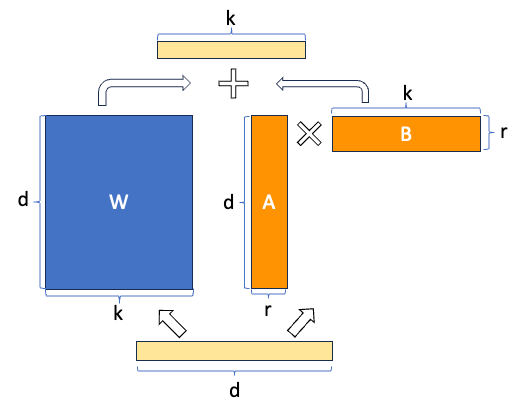

In [ ]:
import argparse
import json
import os
import re
from pathlib import Path
from typing import Dict, List

import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from trl import SFTTrainer


def load_conversations(conversation_dirs: List[str]) -> List[List[Dict]]:
    """Load all .jsonl conversation files, each as a list of messages."""
    conversations = []
    for d in conversation_dirs:
        p = Path(d)
        if not p.exists():
            print(f"Warning: {d} does not exist, skipping.")
            continue
        for f in sorted(p.glob("*.jsonl")):
            if "FAILED" in f.name:
                continue
            msgs = []
            with open(f, encoding="utf-8") as fh:
                for line in fh:
                    line = line.strip()
                    if line:
                        msgs.append(json.loads(line))
            if msgs:
                conversations.append(msgs)
    return conversations


def format_conversation_for_training(
    messages: List[Dict],
    include_reasoning: bool = True,
) -> List[Dict[str, str]]:
    formatted: List[Dict[str, str]] = []

    for msg in messages:
        role = msg["role"]
        content = msg.get("content", "") or ""
        reasoning = msg.get("reasoning", "") or ""

        if role == "system":
            clean = re.sub(
                r"You have a maximum of \d+ turns.*?this limit\.",
                "Use the dictionary tool as many times as needed to produce an accurate translation.",
                content,
                flags=re.DOTALL,
            )
            formatted.append({"role": "system", "content": clean})

        elif role == "user":
            formatted.append({"role": "user", "content": content})

        elif role == "assistant":
            if include_reasoning and reasoning.strip():
                combined = f"<think>\n{reasoning.strip()}\n</think>\n{content}"
            else:
                combined = content
            formatted.append({"role": "assistant", "content": combined})

    return formatted

def build_dataset(
    conversation_dirs: List[str],
    tokenizer,
    include_reasoning: bool = True,
    max_seq_length: int = 4096 * 5,
) -> Dataset:
    raw_convos = load_conversations(conversation_dirs)
    print(f"Loaded {len(raw_convos)} conversations")

    records = []
    skipped = 0
    for convo in raw_convos:
        formatted = format_conversation_for_training(convo, include_reasoning)
        text = tokenizer.apply_chat_template(
            formatted, tokenize=False, add_generation_prompt=False
        )
        token_count = len(tokenizer.encode(text, add_special_tokens=False))
        if token_count > max_seq_length:
            skipped += 1
            continue
        records.append({"text": text})

    print(f"Kept {len(records)} samples, skipped {skipped} (over {max_seq_length} tokens)")
    return Dataset.from_list(records)

def train(
    model_name: str,
    conversation_dirs: List[str],
    output_dir: str,
    include_reasoning: bool = True,
    max_seq_length: int = 20480,
    val_split: float = 0.1,
    load_in_4bit: bool = True,
    load_in_8bit: bool = True,
    flash_attn: bool = False,
    lora_r: int = 16,
    lora_alpha: int = 32,
    lora_dropout: float = 0.05,
    epochs: int = 3,
    batch_size: int = 2,
    gradient_accumulation_steps: int = 8,
    lr: float = 2e-5,
    gradient_checkpointing: bool = True
):
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        padding_side="right",
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    dataset = build_dataset(
        conversation_dirs,
        tokenizer,
        include_reasoning=include_reasoning,
        max_seq_length=max_seq_length,
    )

    if val_split > 0 and len(dataset) > 10:
        split = dataset.train_test_split(test_size=val_split, seed=42)
        train_dataset = split["train"]
        eval_dataset = split["test"]
    else:
        train_dataset = dataset
        eval_dataset = None

    bnb_config = None
    if load_in_4bit:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
        )

    if load_in_8bit:
        bnb_config = BitsAndBytesConfig(
            load_in_8bit=True,
        )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        trust_remote_code=True,
        quantization_config=bnb_config,
        torch_dtype=torch.bfloat16 if not load_in_4bit else None,
        device_map="auto",
        attn_implementation="sdpa" if flash_attn else None,
    )

    if load_in_4bit or load_in_8bit:
        model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=lr,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        weight_decay=0.01,
        bf16=True,
        logging_steps=5,
        save_strategy="epoch",
        eval_strategy="steps" if eval_dataset else "no",
        eval_steps=3,
        save_total_limit=5,
        report_to="none",
        gradient_checkpointing=gradient_checkpointing,
        gradient_checkpointing_kwargs={"use_reentrant": False} if gradient_checkpointing else None,
        optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
        max_grad_norm=1.0,
        seed=42,
        use_liger_kernel=True,
    )

    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
    )

    trainer.train()
    trainer.save_model(os.path.join(output_dir, "final"))
    tokenizer.save_pretrained(os.path.join(output_dir, "final"))
    print(f"\nModel saved to {output_dir}/final")


In [ ]:
train(
    model_name="Qwen/Qwen3.5-2B",
    conversation_dirs=[
        "./conversations_qw_3_6p_2",
    ],
    output_dir="output",
    include_reasoning=True,
    load_in_4bit=False,
    load_in_8bit=True,
    flash_attn=True,
    lora_r=256,
    gradient_checkpointing=False,
    batch_size=1,
    gradient_accumulation_steps=16,
    epochs=5,
)

Loaded 580 conversations
Kept 580 samples, skipped 0 (over 20480 tokens)


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 269,107,200 || all params: 2,150,932,288 || trainable%: 12.5112


Adding EOS to train dataset:   0%|          | 0/522 [00:00<?, ? examples/s]

...

Adding EOS to eval dataset:   0%|          | 0/58 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/58 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A

Step,Training Loss,Validation Loss
3,No log,3.184751
6,3.160664,3.160235
9,3.160664,2.944562
12,3.059507,2.670980
15,2.660151,2.473435
18,2.660151,2.334521
21,2.346943,2.238360
24,2.346943,2.162779
27,2.169440,2.112588
30,2.088882,2.073342


/usr/local/lib/python3.12/dist-packages/transformers/trainer.py:2954: UserWarning: liger-kernel did not return token_accuracy when requested. The mean_token_accuracy metric will not be logged. This is unexpected; please report it to the liger-kernel repository.
  loss, outputs = self.compute_loss(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: 

# Optimización de Prompt

El comportamiento del modelo depende en gran medida de la instrucción que le entreguemos, con lo que surge la pregunta de como escribir un buen prompt. [GEPA](https://arxiv.org/abs/2507.19457) es un método para optimizar de forma automatizada el prompt. Para hacer esto, utiliza un segundo modelo (uno de mayor capacidad por ejemplo) que propone modificaciones y evalúa su desempeño para construir un prompt de manera evolutiva.

Utilizaremos la librería [DSPy](https://dspy.ai/) que incorpora diversas utilidades para trabajar con LLMs, dentro de ellas una implementatión de GEPA para optimizar prompts. Específicamente veremos [este tutorial](https://dspy.ai/tutorials/gepa_facilitysupportanalyzer/).

**IMPORTANTE**: No es necesario ejecutar las celdas de esta sección. En la clase realizamos una demostración corriendo en un servidor externo ya que necesitamos más capacidad de generación para correr en un tiempo razonable.

In [ ]:
import dspy

In [ ]:
import os
import dspy

lm = dspy.LM(
    "openrouter/mistralai/ministral-3b-2512",
    api_base="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY", ""),
    model_type="chat"
)

dspy.configure(lm=lm)

In [ ]:
import requests
import dspy
import json
import random

def init_dataset():
    url = "https://raw.githubusercontent.com/meta-llama/llama-prompt-ops/refs/heads/main/use-cases/facility-support-analyzer/dataset.json"
    dataset = json.loads(requests.get(url).text)
    dspy_dataset = [
        dspy.Example({
            "message": d['fields']['input'],
            "answer": d['answer'],
        }).with_inputs("message")
        for d in dataset
    ]
    random.Random(0).shuffle(dspy_dataset)
    train_set = dspy_dataset[:30] # Para optimizar con GEPA usaremos 30 ejemplos de training y 30 de validación
    val_set = dspy_dataset[30:60]
    # Repetiremos cada ejemplo de testing 5 veces para obtener un promedio del resultado final
    test_set = dspy_dataset[int(len(dspy_dataset) * 0.66):] * 5

    return train_set, val_set, test_set


train_set, val_set, test_set = init_dataset()
len(train_set), len(val_set), len(test_set)

In [ ]:
print("Input Message:")
print(train_set[0]['message'])

print("\n\nGold Answer:")
for k, v in json.loads(train_set[0]['answer']).items():
    print(f"{k}: {v}")

In [ ]:
from typing import List, Literal


class FacilitySupportAnalyzerUrgency(dspy.Signature):
    """
    Read the provided message and determine the urgency.
    """
    message: str = dspy.InputField()
    urgency: Literal['low', 'medium', 'high'] = dspy.OutputField()

class FacilitySupportAnalyzerSentiment(dspy.Signature):
    """
    Read the provided message and determine the sentiment.
    """
    message: str = dspy.InputField()
    sentiment: Literal['positive', 'neutral', 'negative'] = dspy.OutputField()

class FacilitySupportAnalyzerCategories(dspy.Signature):
    """
    Read the provided message and determine the set of categories applicable to the message.
    """
    message: str = dspy.InputField()
    categories: List[Literal["emergency_repair_services", "routine_maintenance_requests", "quality_and_safety_concerns", "specialized_cleaning_services", "general_inquiries", "sustainability_and_environmental_practices", "training_and_support_requests", "cleaning_services_scheduling", "customer_feedback_and_complaints", "facility_management_issues"]] = dspy.OutputField()

class FacilitySupportAnalyzerMM(dspy.Module):
    def __init__(self):
        self.urgency_module = dspy.ChainOfThought(FacilitySupportAnalyzerUrgency)
        self.sentiment_module = dspy.ChainOfThought(FacilitySupportAnalyzerSentiment)
        self.categories_module = dspy.ChainOfThought(FacilitySupportAnalyzerCategories)

    def forward(self, message: str):
        urgency = self.urgency_module(message=message)
        sentiment = self.sentiment_module(message=message)
        categories = self.categories_module(message=message)

        return dspy.Prediction(
            urgency=urgency.urgency,
            sentiment=sentiment.sentiment,
            categories=categories.categories
        )

program = FacilitySupportAnalyzerMM()

In [ ]:
def score_urgency(gold_urgency, pred_urgency):
    """
    Compute score for the urgency module.
    """
    score = 1.0 if gold_urgency == pred_urgency else 0.0
    return score

def score_sentiment(gold_sentiment, pred_sentiment):
    """
    Compute score for the sentiment module.
    """
    score = 1.0 if gold_sentiment == pred_sentiment else 0.0
    return score

def score_categories(gold_categories, pred_categories):
    """
    Compute score for the categories module.
    Uses the same match/mismatch logic as category accuracy in the score.
    """
    correct = 0
    for k, v in gold_categories.items():
        if v and k in pred_categories:
            correct += 1
        elif not v and k not in pred_categories:
            correct += 1
    score = correct / len(gold_categories)
    return score

def metric(example, pred, trace=None, pred_name=None, pred_trace=None):
    gold = json.loads(example['answer'])

    score_urgency_val = score_urgency(gold['urgency'], pred.urgency)
    score_sentiment_val = score_sentiment(gold['sentiment'], pred.sentiment)
    score_categories_val = score_categories(gold['categories'], pred.categories)

    total = (score_urgency_val + score_sentiment_val + score_categories_val) / 3

    return total

In [ ]:
import dspy
evaluate = dspy.Evaluate(
    devset=test_set,
    metric=metric,
    num_threads=5,
    display_table=True,
    display_progress=True
)

evaluate(program)

In [ ]:
import json
import dspy

def feedback_urgency(gold_urgency, pred_urgency):
    """
    Generate feedback for the urgency module.
    """
    score = 1.0 if gold_urgency == pred_urgency else 0.0
    if gold_urgency == pred_urgency:
        feedback = f"You correctly classified the urgency of the message as `{gold_urgency}`. This message is indeed of `{gold_urgency}` urgency."
    else:
        feedback = f"You incorrectly classified the urgency of the message as `{pred_urgency}`. The correct urgency is `{gold_urgency}`. Think about how you could have reasoned to get the correct urgency label."
    return feedback, score

def feedback_sentiment(gold_sentiment, pred_sentiment):
    """
    Generate feedback for the sentiment module.
    """
    score = 1.0 if gold_sentiment == pred_sentiment else 0.0
    if gold_sentiment == pred_sentiment:
        feedback = f"You correctly classified the sentiment of the message as `{gold_sentiment}`. This message is indeed `{gold_sentiment}`."
    else:
        feedback = f"You incorrectly classified the sentiment of the message as `{pred_sentiment}`. The correct sentiment is `{gold_sentiment}`. Think about how you could have reasoned to get the correct sentiment label."
    return feedback, score

def feedback_categories(gold_categories, pred_categories):
    """
    Generate feedback for the categories module.
    Uses the same match/mismatch logic as category accuracy in the score.
    """
    correctly_included = [k for k, v in gold_categories.items() if v and k in pred_categories]
    incorrectly_included = [k for k, v in gold_categories.items() if not v and k in pred_categories]
    incorrectly_excluded = [k for k, v in gold_categories.items() if v and k not in pred_categories]
    correctly_excluded = [k for k, v in gold_categories.items() if not v and k not in pred_categories]  # For completeness in accuracy check

    score = (len(correctly_included) + len(correctly_excluded)) / len(gold_categories)

    if score == 1.0:
        fb_text = f"The category classification is perfect. You correctly identified that the message falls under the following categories: `{repr(correctly_included)}`."
    else:
        fb_text = f"The category classification is not perfect. You correctly identified that the message falls under the following categories: `{repr(correctly_included)}`.\n"
        if incorrectly_included:
            fb_text += f"However, you incorrectly identified that the message falls under the following categories: `{repr(incorrectly_included)}`. The message DOES NOT fall under these categories.\n"
        if incorrectly_excluded:
            prefix = "Additionally, " if incorrectly_included else "However, "
            fb_text += f"{prefix}you didn't identify the following categories that the message actually falls under: `{repr(incorrectly_excluded)}`.\n"
        fb_text += "Think about how you could have reasoned to get the correct category labels."
    return fb_text, score

def metric_with_feedback(example, pred, trace=None, pred_name=None, pred_trace=None):
    """
    Computes a score based on agreement between prediction and gold standard for categories, sentiment, and urgency.
    Optionally provides feedback text for a specific predictor module, using the same comparison logic as the score.
    Returns a dspy.Prediction with score (float) and feedback (str).
    """
    # Parse gold standard from example
    gold = json.loads(example['answer'])

    # Compute feedback and scores for all modules
    fb_urgency, score_urgency = feedback_urgency(gold['urgency'], pred.urgency)
    fb_sentiment, score_sentiment = feedback_sentiment(gold['sentiment'], pred.sentiment)
    fb_categories, score_categories = feedback_categories(gold['categories'], pred.categories)

    # Overall score: average of the three accuracies
    total = (score_urgency + score_sentiment + score_categories) / 3

    if pred_name is None:
        return total

    elif pred_name == 'urgency_module.predict':
        feedback = fb_urgency
    elif pred_name == 'sentiment_module.predict':
        feedback = fb_sentiment
    elif pred_name == 'categories_module.predict':
        feedback = fb_categories

    return dspy.Prediction(score=total, feedback=feedback)

In [ ]:
from dspy import GEPA

optimizer = GEPA(
    metric=metric_with_feedback,
    auto="light", ##
    num_threads=50,
    track_stats=True,
    use_merge=False,
    reflection_lm=dspy.LM(model="gemini/gemini-2.5-flash", temperature=0.7, max_tokens=32000, api_key="")
)

In [ ]:
optimized_program = optimizer.compile(
    program,
    trainset=train_set,
    valset=val_set,
)

In [ ]:
for name, pred in optimized_program.named_predictors():
    print("================================")
    print(f"Predictor: {name}")
    print("================================")
    print("Prompt:")
    print(pred.signature.instructions)
    print("*********************************")

A continuación se encuentra el prompt generado.

```
================================
Predictor: urgency_module.predict
================================
Prompt:
Read the provided message and determine its urgency. The urgency levels are 'low', 'medium', and 'high'.

**Instructions for Determining Urgency:**

1.  **Analyze Keywords and Phrases:**
    *   **High Urgency Indicators:** Look for explicit terms like "urgent," "immediate," "as soon as possible," "critical," "emergency," "can't wait," "serious concern," "needs immediate action," "safety concern," "health risks."
    *   **Medium Urgency Indicators:** Look for terms like "persistent issue," "minor leak," "malfunction," "disruption," "scheduled maintenance," "preventative measure," "important to address," "needs attention by [specific, non-immediate date/time]," "impacts efficiency/comfort."
    *   **Low Urgency Indicators:** Look for terms like "inquiry," "information request," "exploring options," "future planning," "suggestions," "general question," "no immediate issue," "at your earliest convenience" (when not paired with critical issues or existing problems).

2.  **Assess Potential Impact and Consequences of Delay:**
    *   **High Urgency:**
        *   Involves a direct threat to the health, safety, or well-being of individuals (e.g., mold growth with potential health risks, blocked emergency exits, untested fire alarms, structural integrity issues).
        *   Causes significant operational disruption or complete shutdown of critical services that impact core functions.
        *   Poses a risk of severe or irreversible damage to property, sensitive equipment, or data.
        *   Indicates legal or compliance violations that require immediate rectification to avoid penalties or further issues.
        *   The message explicitly states an immediate need due to critical circumstances.
    *   **Medium Urgency:**
        *   Concerns **scheduled or preventative maintenance for critical systems** (e.g., HVAC, plumbing, electrical, IT infrastructure), even if no immediate issues are currently reported. The purpose is to ensure continued functionality, prevent future failures, and maintain a crucial operational environment. **Even if the system is "functioning adequately," routine maintenance for critical infrastructure is essential and not a low priority.**
        *   Addresses *existing* issues causing minor operational inconvenience or a clear potential for future, more significant problems if not addressed within a reasonable timeframe (e.g., a minor but persistent leak, a non-critical equipment malfunction that doesn't halt operations).
        *   Represents significant client dissatisfaction, concerns about company policy, ethics, or brand reputation that require a substantial and timely response to maintain trust and credibility.
        *   Requests services that are important for maintaining operational efficiency, comfort, or a professional environment, but do not pose immediate threats to safety, health, or critical operations.
        *   Messages indicating a need for action within a specific, but not immediate, timeframe (e.g., "sometime next week," "mid-week appointment") for important, but not critical, tasks.
    *   **Low Urgency:**
        *   Comprises purely informational messages or general inquiries that do not require immediate action or address an existing problem.
        *   Requests for information about services, pricing, training programs, or capabilities where the sender is *exploring options* or *planning for the future*, rather than addressing a current operational need or issue. This includes sales inquiries, requests for proposals, or preliminary information gathering.
        *   Requests for non-essential services, minor cosmetic improvements, or general suggestions that have no immediate impact on operations, safety, health, or critical functionality.
        *   Requests with no specific timeline and no significant impact on operations, safety, or health, or where the current situation is completely satisfactory and the request is for a minor enhancement or future consideration.

3.  **Contextual Interpretation:**
    *   Always consider the nature of the facility or environment mentioned (e.g., a police precinct, a recording studio, a hospital, a general office building). What might be "low" urgency in one context could be "medium" or "high" in another due to the specific requirements, regulatory environment, or sensitivities of that environment.
    *   For example, a "routine maintenance request" for an HVAC system in a critical facility (like a precinct, where comfort is "crucial for our team") is classified as `medium` urgency. While it's not an emergency, it's a necessary proactive step to prevent future problems with an essential system and maintain a functional environment. It is not a `low` priority because it directly relates to the upkeep of critical infrastructure.

**General Strategy:**
When classifying, first determine if there is an *existing problem* or *current operational need* that requires attention. If the message is primarily an *inquiry, exploration of options, or future planning* without an immediate existing issue, it is likely `low` urgency. If there is an existing problem, then assess its severity based on impact and keywords.

**Output Format:**
Provide your `reasoning` for the urgency classification, followed by the `urgency` label.
*********************************
================================
Predictor: sentiment_module.predict
================================
Prompt:
Read the provided message and determine its overall sentiment. Classify the sentiment as one of the following: `positive`, `neutral`, or `negative`.

**Guidance for Sentiment Classification:**

*   **Neutral:** This is the default sentiment for transactional messages, service requests, inquiries, or logistical adjustments. A message should be classified as `neutral` if:
    *   Its primary purpose is to request a service (e.g., repair, maintenance, scheduling change), ask for information, or make a transactional adjustment.
    *   It describes an issue or problem (e.g., a severe leak, a malfunctioning HVAC system, difficulty with an online portal), even if the issue is urgent, causes discomfort, or has potential negative consequences (like damage or safety concerns). The *existence of a problem* and its urgency do not automatically make the message's sentiment negative.
    *   The tone is professional, respectful, and focused on seeking a resolution, adjustment, or information, rather than expressing strong negative emotions, blame, or severe dissatisfaction.
    *   It includes minor frustrations, feedback about a process (e.g., a delayed response, difficulty using a system), or suggestions for improvement, as long as these are presented professionally and the overarching goal is a service interaction or constructive communication.
    *   It contains expressions of general appreciation for past services or polite greetings, but the main intent of the message is a new request, adjustment, or problem resolution.

*   **Positive:** A message is `positive` if it expresses genuine satisfaction, praise, gratitude, or commendation. The primary intent of the message must be to convey positive emotion, without being driven by an underlying request for changes, problem resolution, or issues to be addressed.

*   **Negative:** A message is `negative` if it expresses strong dissatisfaction, anger, severe frustration, disappointment, criticism, or blame. This includes overt complaints, grievances, or threats where the primary intent is to convey significant negative emotion or severe disapproval, going beyond a professional request for problem resolution or constructive feedback.

Consider the overall intent and tone of the message. In the context of facility management or customer support, most routine communications involving issues, requests, or adjustments, even if urgent, tend to be `neutral` unless there's a clear and strong emotional deviation indicating severe dissatisfaction or overwhelming praise.
*********************************
================================
Predictor: categories_module.predict
================================
Prompt:
You are an expert message classifier for ProCare Facility Solutions. Your task is to analyze incoming customer messages and assign *ALL* relevant categories from a predefined list.

Here's how to approach the task:

1.  **Understand the Goal:** Identify every single category that accurately describes the content and intent of the message. Do not stop at the most obvious category; you must identify *all* applicable themes.

2.  **Predefined Categories and Their Meanings:**
    *   `quality_and_safety_concerns`: This category applies when the sender expresses concerns about the standards, effectiveness, potential harm, or safety aspects of services, products, or the environment maintained by ProCare. This includes issues related to the safety of people, animals (e.g., pets), or sensitive items (e.g., valuable artifacts, delicate surfaces). It can also cover requests for adjustments to protocols to enhance safety or quality.
    *   `specialized_cleaning_services`: Use this category when the message specifically mentions cleaning products, cleaning methods, or cleaning requirements that are sensitive, unique, or require specific expertise. This includes concerns about residues, potential damage to delicate surfaces (like historical artifacts), or the need for specific types of cleaning solutions (e.g., pet-friendly, non-toxic).
    *   `sustainability_and_environmental_practices`: This category is for messages related to energy efficiency, environmental impact reduction, eco-friendly products, green certifications, sustainable operations, or concerns about the environmental/health impact of current practices or products (e.g., asking for pet-friendly or non-toxic cleaning options).
    *   `general_inquiries`: This category applies to broad requests for information, advice, recommendations, case studies, or a deeper understanding of ProCare's services or capabilities. These are often proactive questions, not tied to an immediate problem or specific service request that requires immediate action.

3.  **Reasoning Process:**
    *   Read the entire message carefully to grasp its full context, intent, and specific details.
    *   Identify the main subject and any secondary topics.
    *   Look for keywords and phrases that directly map to the predefined categories. For example:
        *   "cleaning products," "delicate surfaces," "artifacts," "pet-friendly," "sensitive items" often point to `specialized_cleaning_services`.
        *   "environmental impact," "sustainability," "energy efficiency," "green practices," "pet-friendly products" (when the concern is about the environment/health) often point to `sustainability_and_environmental_practices`.
        *   "inquiry," "seeking advice," "information," "recommendations," "case studies," "deeper understanding" often point to `general_inquiries`.
        *   "quality," "safety," "concerns," "standards," "protocols," "harm," "preservation" often point to `quality_and_safety_concerns`.
    *   Consider the sender's motivation: Are they asking for information? Raising a concern? Seeking advice?
    *   Ensure that for each category you select, you can clearly articulate *why* it applies based on explicit text in the message.

4.  **Output Format:**
    *   `reasoning`: Provide a detailed explanation of why each identified category applies, referencing specific parts of the message. If a category was considered but rejected, briefly explain why.
    *   `categories`: A JSON-formatted list of strings, where each string is an applicable category name from the predefined list. Ensure *all* applicable categories are included.

**Important Considerations:**
*   A single message can (and often will) fall into multiple categories. Your goal is to identify all of them.
*   If a message is an "inquiry" about a specific topic (e.g., sustainability), it should *always* be categorized as both `general_inquiries` and the specific topic (e.g., `sustainability_and_environmental_practices`).
*   Concerns about cleaning products and their effect on sensitive environments (e.g., pets, artifacts) often indicate both `specialized_cleaning_services` and `sustainability_and_environmental_practices` (if related to health/environment) or `quality_and_safety_concerns` (if related to potential harm).
*********************************
```

In [ ]:
import dspy
from typing import List, Literal

class OptimizedFacilitySupportAnalyzerUrgency(dspy.Signature):
    """Read the provided message and determine its urgency. The urgency levels are 'low', 'medium', and 'high'.

**Instructions for Determining Urgency:**

1.  **Analyze Keywords and Phrases:**
    * **High Urgency Indicators:** Look for explicit terms like "urgent," "immediate," "as soon as possible," "critical," "emergency," "can't wait," "serious concern," "needs immediate action," "safety concern," "health risks."
    * **Medium Urgency Indicators:** Look for terms like "persistent issue," "minor leak," "malfunction," "disruption," "scheduled maintenance," "preventative measure," "important to address," "needs attention by [specific, non-immediate date/time]," "impacts efficiency/comfort."
    * **Low Urgency Indicators:** Look for terms like "inquiry," "information request," "exploring options," "future planning," "suggestions," "general question," "no immediate issue," "at your earliest convenience" (when not paired with critical issues or existing problems).

2.  **Assess Potential Impact and Consequences of Delay:**
    * **High Urgency:**
        * Involves a direct threat to the health, safety, or well-being of individuals.
        * Causes significant operational disruption or complete shutdown of critical services.
        * Poses a risk of severe or irreversible damage to property, equipment, or data.
        * Indicates legal or compliance violations requiring immediate rectification.
        * The message explicitly states an immediate need due to critical circumstances.
    * **Medium Urgency:**
        * Concerns **scheduled or preventative maintenance for critical systems** (e.g., HVAC, plumbing, electrical, IT). Even if the system is "functioning adequately," routine maintenance is essential and not a low priority.
        * Addresses *existing* issues causing minor operational inconvenience or potential for future problems.
        * Represents significant client dissatisfaction requiring a substantial response.
        * Requests services important for efficiency or comfort, but not posing immediate threats.
        * Messages indicating a need for action within a specific, but not immediate, timeframe.
    * **Low Urgency:**
        * Comprises purely informational messages or general inquiries.
        * Requests for information where the sender is *exploring options* or *planning for the future*.
        * Requests for non-essential services, minor cosmetic improvements, or general suggestions.
        * Requests with no specific timeline and no significant impact.

3.  **Contextual Interpretation:**
    * Always consider the nature of the facility or environment mentioned. What might be "low" urgency in one context could be "medium" or "high" in another.

**General Strategy:**
When classifying, first determine if there is an *existing problem* or *current operational need*. If the message is primarily an *inquiry, exploration of options, or future planning*, it is likely `low` urgency. If there is an existing problem, then assess its severity.

**Output Format:**
Provide your `reasoning` for the urgency classification, followed by the `urgency` label."""

    message: str = dspy.InputField()
    urgency: Literal['low', 'medium', 'high'] = dspy.OutputField()


class OptimizedFacilitySupportAnalyzerSentiment(dspy.Signature):
    """Read the provided message and determine its overall sentiment. Classify the sentiment as one of the following: `positive`, `neutral`, or `negative`.

**Guidance for Sentiment Classification:**

* **Neutral:** This is the default sentiment for transactional messages, service requests, inquiries, or logistical adjustments. A message should be classified as `neutral` if:
    * Its primary purpose is to request a service, ask for information, or make a transactional adjustment.
    * It describes an issue or problem (even if urgent or uncomfortable). The *existence of a problem* does not automatically make the sentiment negative.
    * The tone is professional, respectful, and focused on seeking a resolution.
    * It includes minor frustrations or feedback presented professionally.
    * It contains general appreciation, but the main intent is a new request.

* **Positive:** A message is `positive` if it expresses genuine satisfaction, praise, gratitude, or commendation. The primary intent must be to convey positive emotion.

* **Negative:** A message is `negative` if it expresses strong dissatisfaction, anger, severe frustration, disappointment, criticism, or blame. This includes overt complaints or threats.

Consider the overall intent and tone of the message. Most routine facility management communications, even if urgent, tend to be `neutral` unless there's a clear emotional deviation."""

    message: str = dspy.InputField()
    sentiment: Literal['positive', 'neutral', 'negative'] = dspy.OutputField()


class OptimizedFacilitySupportAnalyzerCategories(dspy.Signature):
    """You are an expert message classifier for ProCare Facility Solutions. Your task is to analyze incoming customer messages and assign *ALL* relevant categories from a predefined list.

Here's how to approach the task:

1.  **Understand the Goal:** Identify every single category that accurately describes the content and intent of the message. Do not stop at the most obvious category.

2.  **Predefined Categories and Their Meanings:**
    * `quality_and_safety_concerns`: Concerns about standards, effectiveness, potential harm, or safety aspects.
    * `specialized_cleaning_services`: Mentions cleaning products, methods, or requirements that are sensitive or unique (e.g., delicate surfaces, pet-friendly).
    * `sustainability_and_environmental_practices`: Related to energy efficiency, eco-friendly products, or environmental impact.
    * `general_inquiries`: Broad requests for information, advice, or deeper understanding, not tied to an immediate problem.

3.  **Reasoning Process:**
    * Read the entire message carefully.
    * Look for keywords mapping to categories (e.g., "delicate surfaces" -> `specialized_cleaning_services`).
    * Consider the sender's motivation.
    * Ensure you can articulate *why* a category applies based on explicit text.

4.  **Output Format:**
    * `reasoning`: Provide a detailed explanation of why each identified category applies.
    * `categories`: A JSON-formatted list of strings from the predefined list.

**Important Considerations:**
* A single message can fall into multiple categories.
* An "inquiry" about a specific topic should be categorized as both `general_inquiries` and the specific topic.
* Concerns about cleaning products on sensitive environments often indicate both `specialized_cleaning_services` and `sustainability_and_environmental_practices` or `quality_and_safety_concerns`."""

    message: str = dspy.InputField()
    categories: List[Literal["emergency_repair_services", "routine_maintenance_requests", "quality_and_safety_concerns", "specialized_cleaning_services", "general_inquiries", "sustainability_and_environmental_practices", "training_and_support_requests", "cleaning_services_scheduling", "customer_feedback_and_complaints", "facility_management_issues"]] = dspy.OutputField()

In [ ]:
class OptimizedFacilitySupportAnalyzerMM(dspy.Module):
    def __init__(self):
        self.urgency_module = dspy.ChainOfThought(OptimizedFacilitySupportAnalyzerUrgency)
        self.sentiment_module = dspy.ChainOfThought(OptimizedFacilitySupportAnalyzerSentiment)
        self.categories_module = dspy.ChainOfThought(OptimizedFacilitySupportAnalyzerCategories)

    def forward(self, message: str):
        urgency = self.urgency_module(message=message)
        sentiment = self.sentiment_module(message=message)
        categories = self.categories_module(message=message)

        return dspy.Prediction(
            urgency=urgency.urgency,
            sentiment=sentiment.sentiment,
            categories=categories.categories
        )

optimized_program = OptimizedFacilitySupportAnalyzerMM()

In [ ]:
import dspy
evaluate = dspy.Evaluate(
    devset=test_set,
    metric=metric,
    num_threads=5,
    display_table=True,
    display_progress=True
)

evaluate(optimized_program)

# Actividades

## Actividad 1

### Pregunta 1 (1.33 puntos)

Una de las dificultades de trabajar con secuencias de tamano muy grande (decenas de miles o cientos de miles de tokens) es que los modelos comienzan a presentar problemas y disminuye fuertemente su capacidad de utilizar el contenido en ese contexto.

Investigue y describa otros 2 problemas relacionados a utilizar contextos muy grandes (Ayuda: Estos estan relacionados entre si y el uso de tecnicas de atencion tipo sparse o atencion tipo lineal son utilizadas como mitigacion. No es necesario investigar sobre esta tecnicas, es solo para facilitar su busqueda). Un par de oraciones es suficiente por problema.

### Pregunta 2 (0.66 puntos)

Modelos como los de la familia Qwen 3.5 o Gemma 4 son de tipo hibrido, son capaces de generar con trazas de razonamiento (texto entre las etiquetas _\<think\>\<\/think\>_ antes de la respuesta final presentada al usuario), o saltandose la etapa de razonamiento y generando la respuesta final directamente.

**Cual es la utilidad de poder deshabilitar la generacion con modo de razonamiento?**

## Actividad 2

Busque sobre cómo utilizar el modelo _Qwen/Qwen3-VL-2B-Thinking_ para trabajar con texto e imágenes. Luego utilice este modelo para:
  - Generar una descripción de la imágen _sample-food.jpeg_
  - Generar _bounding boxes_ (extracción de regiones) de los objetos en la imágen _sample-food.jpeg_ (Ayuda: Puede utilizar la siguiente instrucción _Generate bounding boxes for the objects in the image._).
  - De la imágen _boleta.png_ extraer número de boleta, artículos vendidos, unidades de cada artículo vendido, precio unitario, fecha de venta, y estructurar estos valores en un JSON (la salida del modelo debe contener una sección de texto con estructura JSON).

(1,33 puntos cada una)

  Para la extracción de _bounding boxes_, dibuje los rectángulos sobre la imágen. A continuación se incluye código para realizar esto.

In [ ]:
# Descarga imágenes

!gdown 1AfQ72ybSTr5oUqhsyyVNwBGbBsna74b8
!gdown 12HmBb4GqpzkuIoe8kl8mPp04qgkZOirj

In [ ]:
import json
import random
import io
import ast
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont
from PIL import ImageColor
import xml.etree.ElementTree as ET

additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

def parse_json(json_output):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output


def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    if not isinstance(bounding_boxes, list):
      json_output = [bounding_boxes]

    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(bounding_boxes):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["bbox_2d"][1] / 1000 * height)
      abs_x1 = int(bounding_box["bbox_2d"][0] / 1000 * width)
      abs_y2 = int(bounding_box["bbox_2d"][3] / 1000 * height)
      abs_x2 = int(bounding_box["bbox_2d"][2] / 1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=3
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color)

    # Display the image
    img.show()

In [ ]:
boxes_text = """```json
[{"bbox_2d": [232, 100, 709, 370], "label": "soup"}]
```
"""
image = Image.open("sample-food.jpeg")
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, json.loads(parse_json(boxes_text)))

image

## Actividad 1: Descripción de imagen

Generar una descripción textual de la imagen sample-food.jpeg utilizando el modelo multimodal.

In [ ]:
# ========================================
# ACTIVIDAD 1: Descripción de imagen
# ========================================
# Tarea: Generar descripción textual de sample-food.jpeg
# Pasos:
#   1. Cargar la imagen sample-food.jpeg
#   2. Usar el modelo para generar descripción
#   3. Imprimir resultado

print("\n=== ACTIVIDAD 1: Descripción de imagen ===")
image1 = Image.open("sample-food.jpeg")

# Prompt para la descripción
description_prompt = 'Describe detalladamente lo que ves en esta imagen. Incluye los alimentos, colores, presentación y cualquier detalle relevante.'

# Generar descripción usando el modelo vision
description_response = model.generate_content([description_prompt, image1])
description_text = description_response.text

print("Descripción generada:")
print(description_text)

## Actividad 2: Extracción de bounding boxes

Generar coordenadas de bounding boxes para los objetos detectados en sample-food.jpeg. Copiar la salida JSON del modelo en la función plot_bounding_boxes.

In [ ]:
# ========================================
# ACTIVIDAD 2: Extracción de bounding boxes
# ========================================
# Tarea: Detectar objetos y generar coordenadas de bounding boxes
# Pasos:
#   1. Usar el modelo para detectar objetos
#   2. Generar coordenadas en formato JSON
#   3. Visualizar con la función plot_bounding_boxes

print("\n=== ACTIVIDAD 2: Bounding boxes ===")

# Prompt para generar bounding boxes
bbox_prompt = '''Analiza la imagen y detecta todos los objetos principales (alimentos, recipientes, etc.).

Para cada objeto, genera un JSON con estructura:
{
  "bbox_2d": [x1_mnormalized, y1_normalized, x2_normalized, y2_normalized],  // Valores 0-1000
  "label": "nombre del objeto"
}

Retorna SOLO el JSON array válido, sin markdown ni explicación adicional.'''

# Generar bounding boxes
bbox_response = model.generate_content([bbox_prompt, image1])
bbox_text = bbox_response.text

print("Respuesta del modelo (JSON):")
print(bbox_text)

# Intentar parsear y visualizar
try:
    bbox_list = json.loads(parse_json(bbox_text))
    plot_bounding_boxes(image1, bbox_list)
except Exception as e:
    print(f"Nota: Copiar el JSON generado arriba en la función plot_bounding_boxes para visualizar.")

## Actividad 3: Extracción de datos de boleta

Extraer de boleta.png: número de boleta, artículos, unidades, precios unitarios, fecha. Estructurar en JSON.

In [ ]:
# ========================================
# ACTIVIDAD 3: Extracción de datos de boleta
# ========================================
# Tarea: Extraer información estructurada de un recibo/boleta
# Pasos:
#   1. Cargar imagen de boleta
#   2. Usar modelo para extraer datos
#   3. Retornar en formato JSON

print("\n=== ACTIVIDAD 3: Extracción de boleta ===")

# Verificar si existe el archivo boleta.png
if os.path.exists("boleta.png"):
    boleta_image = Image.open("boleta.png")

    # Prompt para extracción de datos
    receipt_prompt = '''Extrae la siguiente información de esta boleta/recibo y retorna SOLO un JSON válido:

{
  "numero_boleta": "número de boleta",
  "fecha_venta": "fecha en formato YYYY-MM-DD",
  "articulos": [
    {
      "nombre": "nombre del artículo",
      "unidades": número,
      "precio_unitario": número,
      "subtotal": número
    }
  ],
  "total": número
}

Retorna SOLO el JSON, sin markdown.'''

    # Generar extracción
    receipt_response = model.generate_content([receipt_prompt, boleta_image])
    receipt_data = receipt_response.text

    print("Datos extraídos de la boleta:")
    print(receipt_data)

    # Intentar validar JSON
    try:
        parsed_receipt = json.loads(parse_json(receipt_data))
        print("\nJSON validado correctamente:")
        print(json.dumps(parsed_receipt, indent=2, ensure_ascii=False))
    except Exception as e:
        print("Nota: Copiar el JSON generado arriba para guardar/procesar.")
else:
    print("Archivo boleta.png no encontrado. Asegúrate de que esté en el directorio de trabajo.")